In [7]:
#1.Import Libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import keras
import matplotlib.pyplot as plt
import numpy as np


In [10]:
#2. Load the dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 27s 0us/step


c:\Users\2021393076\Desktop\Deeplabact-Raheeq\tfenv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


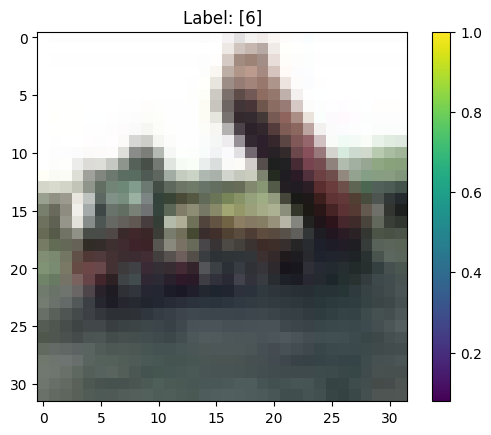

In [15]:
#3.Visualize the data
plt.figure()
plt.imshow(train_images[2]) # Display the first image in the plot area
plt.colorbar()
plt.title(f"Label: {train_labels[0]}") # Displays the label of the first image
plt.grid(False)
plt.show() # Render and displaysthe plot window.

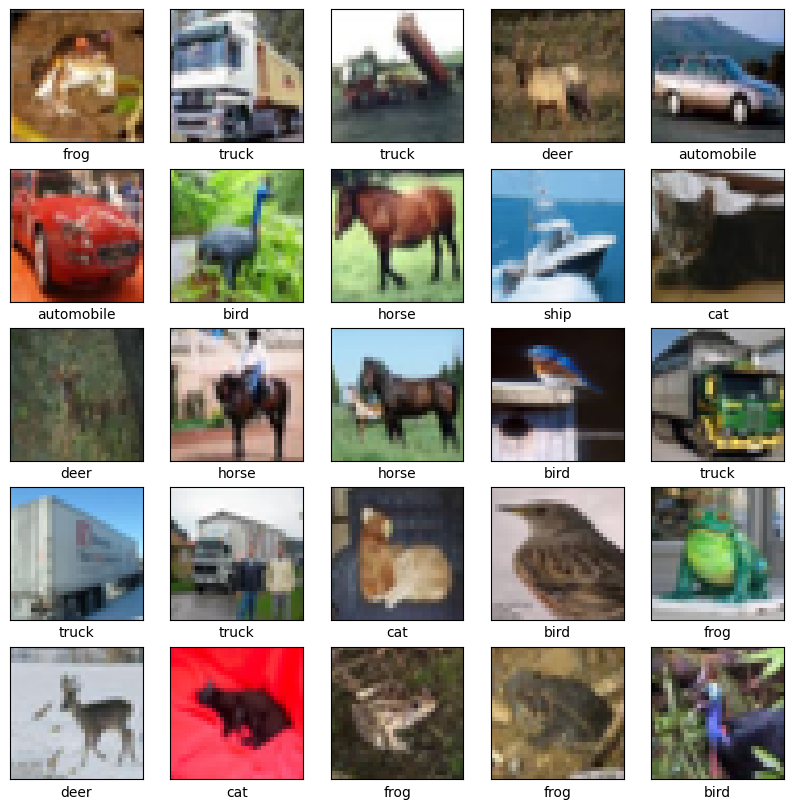

In [16]:
#lables
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [17]:
#4.Build the Neural Network Model. 
model = models.Sequential()
model.add(layers.Input(shape=(32,32,3))) #32*32 is pixle, 3 colors RGB
model.add(layers.Conv2D(32, (3, 3), activation='relu')) #32 numbers of filters, size of filter is 3*3
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
#Add Dense layers on top
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
#Compile the Model.  
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [20]:
#5.Train the Model. 
history = model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4298 - loss: 1.5570 - val_accuracy: 0.5256 - val_loss: 1.3226
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5803 - loss: 1.1818 - val_accuracy: 0.6152 - val_loss: 1.0925
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6396 - loss: 1.0248 - val_accuracy: 0.6437 - val_loss: 1.0169
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6796 - loss: 0.9175 - val_accuracy: 0.6645 - val_loss: 0.9616
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7054 - loss: 0.8404 - val_accuracy: 0.6836 - val_loss: 0.9015
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7247 - loss: 0.7798 - val_accuracy: 0.6925 - val_loss: 0.8866
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7440 - loss: 0.7307 - val_accuracy: 0.7002 - val_loss: 0.8651
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7578 - loss: 0.6892 - 

313/313 - 0s - 1ms/step - accuracy: 0.7197 - loss: 0.8373
Test Accuracy:  71.96999788284302 %
Test Loss:  0.8372846841812134


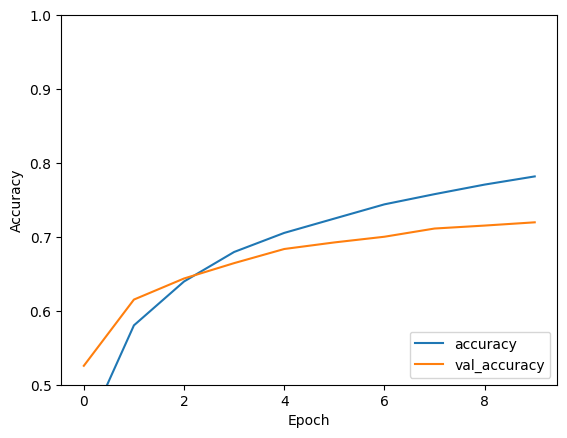

In [24]:
#6. Evaluate the Model
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

#important 
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print( "Test Accuracy: " , test_acc * 100, "%")
print( "Test Loss: " , test_loss)

In [22]:
#7. Make predictions

probability_model = models.Sequential([
    model,                         # The trained model (outputs logits/raw scores)
    layers.Softmax()       # Convert raw scores into probabilities
])

predictions = probability_model.predict(test_images)  # Predict probabilities for test images

print(predictions)
predicted_value=np.argmax(predictions[0])
print(predicted_value)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[1.3036622e-03 5.7082443e-04 5.9308959e-03 ... 2.9847003e-04
  3.5435557e-03 2.5861352e-04]
 [5.9916254e-02 1.5426014e-01 2.7597493e-05 ... 6.3036100e-06
  7.7846217e-01 7.3115905e-03]
 [1.6955212e-01 1.9127863e-02 6.0742797e-04 ... 1.1803251e-02
  7.5960451e-01 3.0745002e-02]
 ...
 [1.1700976e-04 2.6810558e-06 3.6901634e-02 ... 6.2352316e-03
  1.7732040e-04 3.2192372e-06]
 [8.9918561e-02 5.2315593e-01 4.2294394e-03 ... 2.3708804e-02
  4.4800630e-03 9.9544798e-04]
 [3.3818143e-08 1.9439981e-09 7.7053613e-07 ... 9.9891555e-01
  2.1939211e-08 6.1424153e-08]]
3


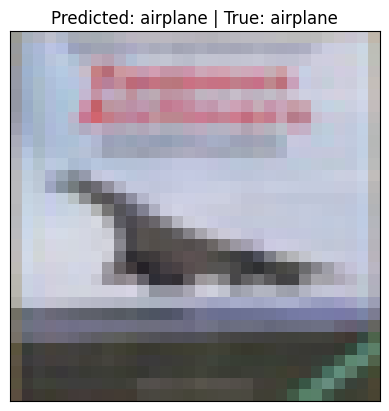

Predicted Label: airplane
True Label: airplane


In [23]:
#8. Display a predicted image with its predicted and true label

index = predicted_value   # You can change this to test other images

plt.figure()
plt.imshow(test_images[index])
plt.xticks([])
plt.yticks([])
plt.grid(False)

predicted_label = class_names[np.argmax(predictions[index])]
true_label = class_names[test_labels[index][0]]

plt.title("Predicted: " + predicted_label + " | True: " + true_label)
plt.show()

print("Predicted Label:", predicted_label)
print("True Label:", true_label)